# CNN Optimization — 실험
- 트랙 A (#1~#5): Baseline 기반 규제 중심 접근
- 트랙 B (#6~#12): 아키텍처 재설계 기반 접근
- 모든 실험은 직전 실험과 **한 가지 요소만** 다름

In [1]:
# 셋업
%load_ext autoreload
%autoreload 2
import sys; sys.path.append('..')

import numpy as np, torch, torch.nn as nn, torch.optim as optim
from sklearn.metrics import f1_score
from src.utils import (set_seed, get_device, load_split, make_loaders,
                       get_class_weights, evaluate, minor_recall, full_report,
                       train_model, plot_curves, log_result,
                       CLASS_NAMES, MINOR_IDX)
from src.models import BaselineCNN, ImprovedCNN, count_params

SEED = 42
device = get_device()
data = load_split()
print(device, {k: v.shape for k, v in data.items() if k.startswith('X')})

RESULTS = '../results/results.csv'

# 트랙 A/B 공용 로더 (증강 없음)
set_seed(SEED)
train_loader, valid_loader, test_loader = make_loaders(data, batch_size=64, seed=SEED)

mps {'X_train': (18311, 1, 64, 64), 'X_valid': (6104, 1, 64, 64), 'X_test': (6104, 1, 64, 64)}


In [2]:
# 파라미터 분포
print("=== Baseline ===")
count_params(BaselineCNN())
print("\n=== ImprovedCNN ===")
count_params(ImprovedCNN())

=== Baseline ===
layer                         params    share
---------------------------------------------
layer1.0                         320     0.0%
layer2.0                      18,496     2.2%
fc.1                         802,880    97.6%
fc.3                             585     0.1%
---------------------------------------------
TOTAL                        822,281

=== ImprovedCNN ===
layer                         params    share
---------------------------------------------
features.0.0                     320     0.1%
features.0.1                      64     0.0%
features.1.0                  18,496     7.6%
features.1.1                     128     0.1%
features.2.0                  73,856    30.5%
features.2.1                     256     0.1%
features.3.0                 147,584    61.0%
features.3.1                     256     0.1%
head.1                         1,161     0.5%
---------------------------------------------
TOTAL                        242,121


242121

## 트랙 A — 규제 중심 접근
Baseline 구조를 유지한 채 규제를 하나씩 누적. patience=5 통일.

Ep  1  tr_loss 0.9045 tr_acc  66.33 | va_loss 0.6819 va_acc  75.07 va_F1 0.6345 va_minor 0.6155 *
Ep  2  tr_loss 0.6047 tr_acc  77.77 | va_loss 0.6291 va_acc  76.92 va_F1 0.6929 va_minor 0.8630 *
Ep  3  tr_loss 0.5058 tr_acc  81.98 | va_loss 0.5037 va_acc  82.62 va_F1 0.7438 va_minor 0.8108 *
Ep  4  tr_loss 0.4233 tr_acc  84.65 | va_loss 0.5186 va_acc  82.06 va_F1 0.6432 va_minor 0.5772
Ep  5  tr_loss 0.3561 tr_acc  87.46 | va_loss 0.4588 va_acc  84.60 va_F1 0.7464 va_minor 0.8514 *
Ep  6  tr_loss 0.3049 tr_acc  89.34 | va_loss 0.4507 va_acc  84.68 va_F1 0.7663 va_minor 0.7994 *
Ep  7  tr_loss 0.2426 tr_acc  91.40 | va_loss 0.5269 va_acc  82.98 va_F1 0.7419 va_minor 0.8634
Ep  8  tr_loss 0.1873 tr_acc  93.70 | va_loss 0.4812 va_acc  84.37 va_F1 0.7591 va_minor 0.9153
Ep  9  tr_loss 0.1405 tr_acc  95.52 | va_loss 0.5525 va_acc  83.91 va_F1 0.7745 va_minor 0.9028 *
Ep 10  tr_loss 0.1061 tr_acc  96.60 | va_loss 0.5831 va_acc  83.17 va_F1 0.7742 va_minor 0.8954
Ep 11  tr_loss 0.0806 tr_acc

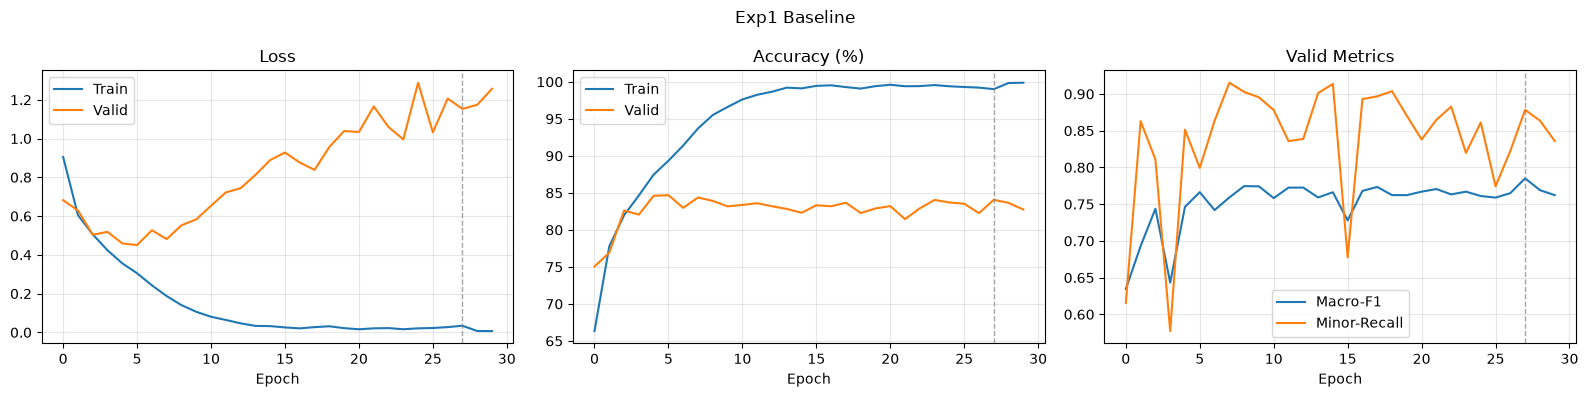

              precision    recall  f1-score   support

      Center     0.9186    0.9453    0.9317       859
       Donut     0.8364    0.8288    0.8326       111
    Edge-Loc     0.7889    0.7958    0.7923      1038
   Edge-Ring     0.9591    0.9804    0.9696      1936
         Loc     0.7323    0.6630    0.6959       718
   Near-full     1.0000    0.9333    0.9655        30
      Random     0.8162    0.8728    0.8436       173
     Scratch     0.3643    0.2134    0.2691       239
        none     0.7373    0.7970    0.7660      1000

    accuracy                         0.8406      6104
   macro avg     0.7948    0.7811    0.7851      6104
weighted avg     0.8321    0.8406    0.8351      6104

logged: exp1


In [3]:
# 실험 #1 Baseline
set_seed(SEED)
model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

hist = train_model(model, train_loader, valid_loader, criterion, optimizer, device,
                   epochs=30, patience=None,          # 과적합 관찰용: ES 없이 끝까지
                   ckpt_path='../ckpt/exp1_best.pt')
plot_curves(hist, 'Exp1 Baseline', '../results/figures/exp1_curves.png')
_, _, yt, yp = evaluate(model, valid_loader, criterion, device)
full_report(yt, yp)
log_result(RESULTS, 1, 'Baseline', 'epochs=30, lr=1e-3, ES 없음', hist, yt, yp)

Ep  1  tr_loss 0.9086 tr_acc  66.24 | va_loss 0.7141 va_acc  74.38 va_F1 0.5851 va_minor 0.5287 *
Ep  2  tr_loss 0.6209 tr_acc  77.32 | va_loss 0.5929 va_acc  79.33 va_F1 0.6899 va_minor 0.6679 *
Ep  3  tr_loss 0.5293 tr_acc  80.71 | va_loss 0.5353 va_acc  80.90 va_F1 0.6804 va_minor 0.5578
Ep  4  tr_loss 0.4378 tr_acc  84.10 | va_loss 0.5161 va_acc  81.11 va_F1 0.7428 va_minor 0.7817 *
Ep  5  tr_loss 0.3694 tr_acc  86.58 | va_loss 0.4730 va_acc  83.17 va_F1 0.7523 va_minor 0.8698 *
Ep  6  tr_loss 0.3037 tr_acc  89.26 | va_loss 0.4748 va_acc  83.96 va_F1 0.7688 va_minor 0.7994 *
Ep  7  tr_loss 0.2487 tr_acc  91.49 | va_loss 0.4794 va_acc  83.98 va_F1 0.7914 va_minor 0.9340 *
Ep  8  tr_loss 0.1861 tr_acc  93.75 | va_loss 0.5451 va_acc  84.06 va_F1 0.7739 va_minor 0.8451
Ep  9  tr_loss 0.1463 tr_acc  95.04 | va_loss 0.5558 va_acc  83.73 va_F1 0.7737 va_minor 0.8823
Ep 10  tr_loss 0.1001 tr_acc  97.06 | va_loss 0.5980 va_acc  83.75 va_F1 0.7447 va_minor 0.6928
Ep 11  tr_loss 0.0735 tr_acc

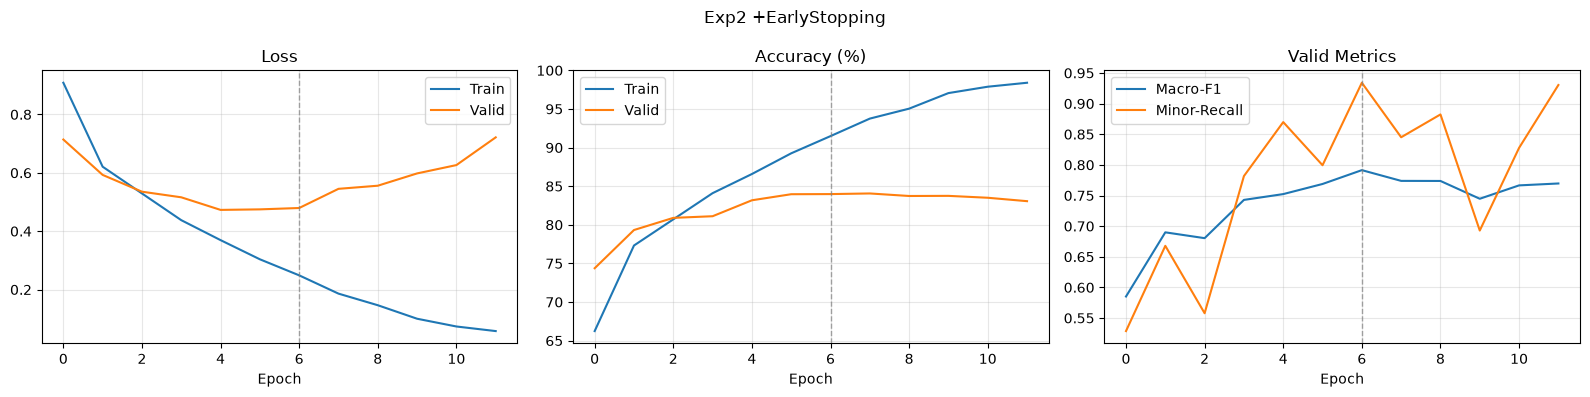

              precision    recall  f1-score   support

      Center     0.9333    0.9278    0.9305       859
       Donut     0.7687    0.9279    0.8408       111
    Edge-Loc     0.8105    0.7909    0.8006      1038
   Edge-Ring     0.9396    0.9881    0.9632      1936
         Loc     0.7354    0.7006    0.7175       718
   Near-full     0.8788    0.9667    0.9206        30
      Random     0.8579    0.9075    0.8820       173
     Scratch     0.3162    0.3096    0.3129       239
        none     0.7814    0.7290    0.7543      1000

    accuracy                         0.8398      6104
   macro avg     0.7802    0.8054    0.7914      6104
weighted avg     0.8367    0.8398    0.8376      6104

logged: exp2


In [4]:
# 실험 #2 +Early Stopping
set_seed(SEED)
model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

hist = train_model(model, train_loader, valid_loader, criterion, optimizer, device,
                   epochs=50, patience=5, ckpt_path='../ckpt/exp2_best.pt')
plot_curves(hist, 'Exp2 +EarlyStopping', '../results/figures/exp2_curves.png')
_, _, yt, yp = evaluate(model, valid_loader, criterion, device)
full_report(yt, yp)
log_result(RESULTS, 2, '+Early Stopping', 'patience=5', hist, yt, yp)

Center      0.790
Donut       6.110
Edge-Loc    0.654
Edge-Ring   0.350
Loc         0.944
Near-full   22.860
Random      3.913
Scratch     2.842
none        0.678
Ep  1  tr_loss 1.2297 tr_acc  56.24 | va_loss 0.9666 va_acc  64.06 va_F1 0.5614 va_minor 0.8175 *
Ep  2  tr_loss 0.7739 tr_acc  70.62 | va_loss 0.7196 va_acc  72.03 va_F1 0.6609 va_minor 0.9464 *
Ep  3  tr_loss 0.6846 tr_acc  74.16 | va_loss 0.6980 va_acc  76.74 va_F1 0.6750 va_minor 0.9475 *
Ep  4  tr_loss 0.5869 tr_acc  77.45 | va_loss 0.6332 va_acc  77.74 va_F1 0.6966 va_minor 0.9357 *
Ep  5  tr_loss 0.5048 tr_acc  80.04 | va_loss 0.6485 va_acc  74.52 va_F1 0.7130 va_minor 0.8960 *
Ep  6  tr_loss 0.4391 tr_acc  82.74 | va_loss 0.6052 va_acc  78.36 va_F1 0.7335 va_minor 0.9179 *
Ep  7  tr_loss 0.4040 tr_acc  84.73 | va_loss 0.6902 va_acc  74.61 va_F1 0.6878 va_minor 0.9478
Ep  8  tr_loss 0.3267 tr_acc  87.63 | va_loss 0.7210 va_acc  80.50 va_F1 0.7531 va_minor 0.9014 *
Ep  9  tr_loss 0.2536 tr_acc  90.33 | va_loss 0.7428 va

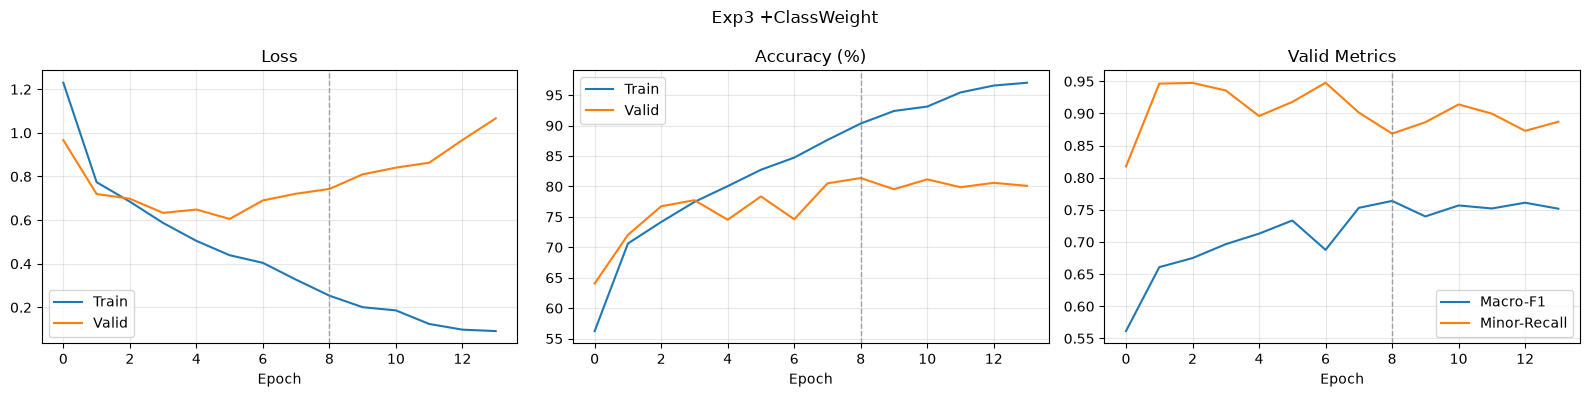

              precision    recall  f1-score   support

      Center     0.9049    0.9418    0.9230       859
       Donut     0.8585    0.8198    0.8387       111
    Edge-Loc     0.7434    0.7900    0.7660      1038
   Edge-Ring     0.9864    0.9385    0.9619      1936
         Loc     0.7215    0.5738    0.6393       718
   Near-full     0.8333    1.0000    0.9091        30
      Random     0.9189    0.7861    0.8474       173
     Scratch     0.2760    0.2552    0.2652       239
        none     0.6686    0.7910    0.7247      1000

    accuracy                         0.8137      6104
   macro avg     0.7680    0.7663    0.7639      6104
weighted avg     0.8176    0.8137    0.8133      6104

logged: exp3


In [6]:
# 실험 #3 +Class Weight
set_seed(SEED)
w = get_class_weights(data['y_train'], device)
for c, v in zip(CLASS_NAMES, w.cpu().numpy()):
    print(f'{c:<12}{v:.3f}')

model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss(weight=w)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

hist = train_model(model, train_loader, valid_loader, criterion, optimizer, device,
                   epochs=50, patience=5, ckpt_path='../ckpt/exp3_best.pt')
plot_curves(hist, 'Exp3 +ClassWeight', '../results/figures/exp3_curves.png')
_, _, yt, yp = evaluate(model, valid_loader, criterion, device)
full_report(yt, yp)
log_result(RESULTS, 3, '+Class Weight', 'balanced', hist, yt, yp)

Ep  1  tr_loss 1.4510 tr_acc  48.92 | va_loss 0.9076 va_acc  58.80 va_F1 0.5539 va_minor 0.8855 *
Ep  2  tr_loss 0.9888 tr_acc  61.97 | va_loss 0.7994 va_acc  69.69 va_F1 0.6327 va_minor 0.9259 *
Ep  3  tr_loss 0.9183 tr_acc  65.06 | va_loss 0.7870 va_acc  65.78 va_F1 0.5968 va_minor 0.9573
Ep  4  tr_loss 0.8102 tr_acc  67.57 | va_loss 0.8330 va_acc  66.71 va_F1 0.5543 va_minor 0.9406
Ep  5  tr_loss 0.7784 tr_acc  68.90 | va_loss 0.6856 va_acc  72.05 va_F1 0.6766 va_minor 0.9479 *
Ep  6  tr_loss 0.7261 tr_acc  70.53 | va_loss 0.7069 va_acc  75.43 va_F1 0.7087 va_minor 0.8785 *
Ep  7  tr_loss 0.6953 tr_acc  72.19 | va_loss 0.6445 va_acc  75.08 va_F1 0.6945 va_minor 0.9408
Ep  8  tr_loss 0.7010 tr_acc  72.13 | va_loss 0.6537 va_acc  76.77 va_F1 0.7080 va_minor 0.9535
Ep  9  tr_loss 0.6447 tr_acc  74.20 | va_loss 0.6423 va_acc  78.00 va_F1 0.7192 va_minor 0.9299 *
Ep 10  tr_loss 0.6027 tr_acc  75.86 | va_loss 0.6443 va_acc  77.85 va_F1 0.7219 va_minor 0.9169 *
Ep 11  tr_loss 0.5793 tr_acc

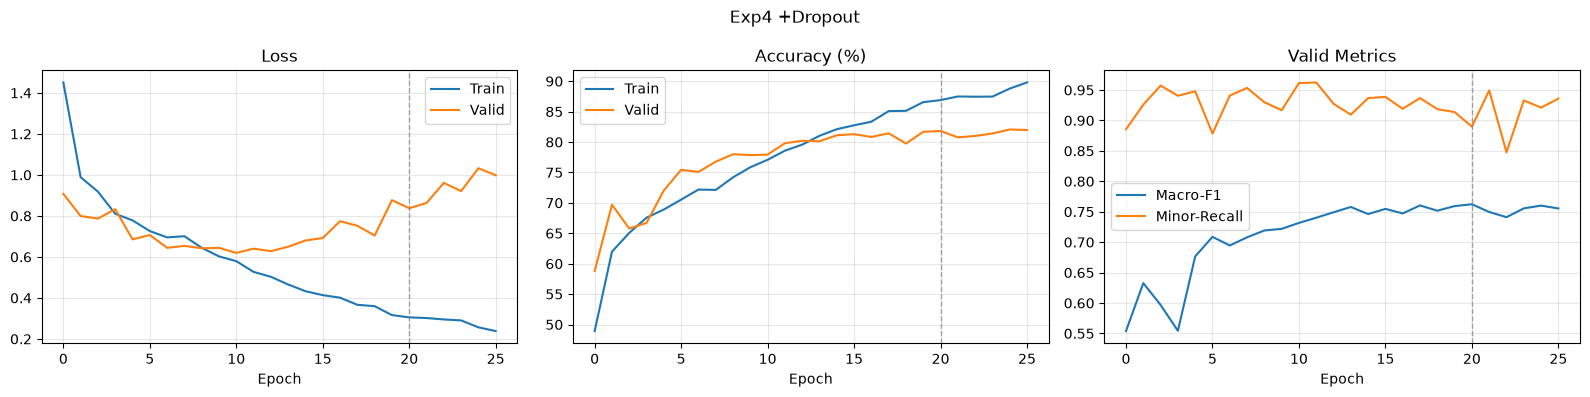

              precision    recall  f1-score   support

      Center     0.9216    0.9034    0.9124       859
       Donut     0.8198    0.8198    0.8198       111
    Edge-Loc     0.7811    0.7736    0.7773      1038
   Edge-Ring     0.9721    0.9716    0.9718      1936
         Loc     0.6136    0.6657    0.6386       718
   Near-full     0.7500    1.0000    0.8571        30
      Random     0.9130    0.8497    0.8802       173
     Scratch     0.2967    0.2594    0.2768       239
        none     0.7267    0.7260    0.7264      1000

    accuracy                         0.8182      6104
   macro avg     0.7550    0.7744    0.7623      6104
weighted avg     0.8182    0.8182    0.8179      6104

logged: exp4


In [7]:
# 실험 #4 +Dropout
set_seed(SEED)
w = get_class_weights(data['y_train'], device)

model = BaselineCNN(dropout=0.4).to(device)
criterion = nn.CrossEntropyLoss(weight=w)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

hist = train_model(model, train_loader, valid_loader, criterion, optimizer, device,
                   epochs=50, patience=5, ckpt_path='../ckpt/exp4_best.pt')
plot_curves(hist, 'Exp4 +Dropout', '../results/figures/exp4_curves.png')
_, _, yt, yp = evaluate(model, valid_loader, criterion, device)
full_report(yt, yp)
log_result(RESULTS, 4, '+Dropout', 'p=0.4', hist, yt, yp)

Ep  1  tr_loss 1.5690 tr_acc  44.75 | va_loss 1.0067 va_acc  63.01 va_F1 0.5451 va_minor 0.8503 *
Ep  2  tr_loss 1.1164 tr_acc  57.03 | va_loss 0.8915 va_acc  61.52 va_F1 0.5952 va_minor 0.9021 *
Ep  3  tr_loss 1.0126 tr_acc  59.95 | va_loss 0.8443 va_acc  64.38 va_F1 0.6049 va_minor 0.9077 *
Ep  4  tr_loss 0.9465 tr_acc  61.94 | va_loss 0.7948 va_acc  72.03 va_F1 0.6350 va_minor 0.9068 *
Ep  5  tr_loss 0.8874 tr_acc  64.05 | va_loss 0.7837 va_acc  68.59 va_F1 0.6320 va_minor 0.9309
Ep  6  tr_loss 0.8422 tr_acc  65.25 | va_loss 0.6940 va_acc  72.89 va_F1 0.6720 va_minor 0.9317 *
Ep  7  tr_loss 0.8388 tr_acc  65.65 | va_loss 0.7348 va_acc  69.27 va_F1 0.6305 va_minor 0.9217
Ep  8  tr_loss 0.7944 tr_acc  67.10 | va_loss 0.7080 va_acc  72.05 va_F1 0.6685 va_minor 0.9383
Ep  9  tr_loss 0.7473 tr_acc  69.13 | va_loss 0.7391 va_acc  74.33 va_F1 0.6522 va_minor 0.9329
Ep 10  tr_loss 0.7231 tr_acc  69.60 | va_loss 0.6549 va_acc  76.38 va_F1 0.7019 va_minor 0.9378 *
Ep 11  tr_loss 0.7179 tr_acc

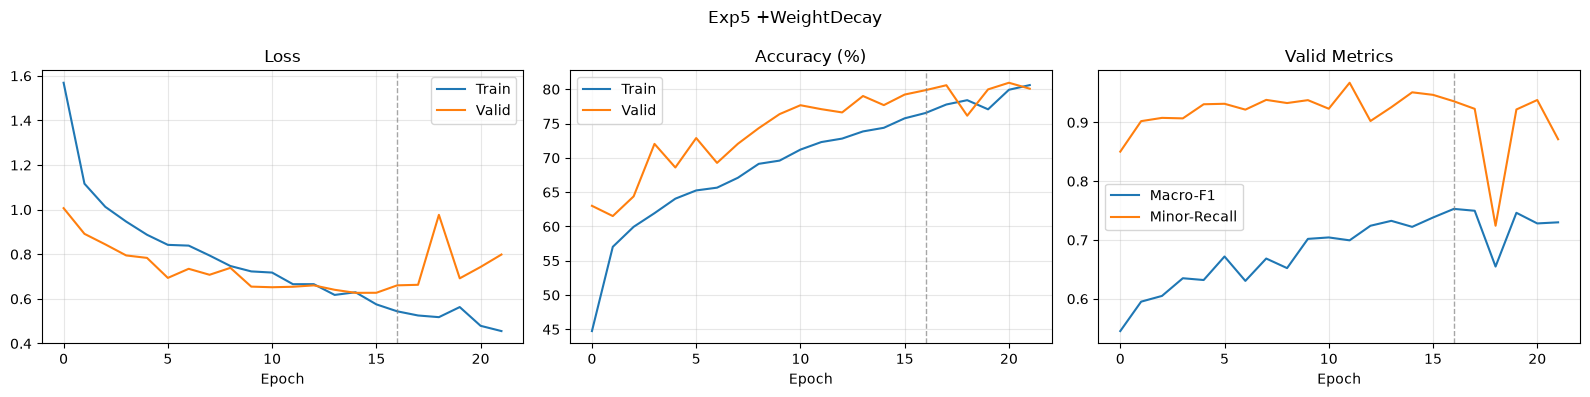

              precision    recall  f1-score   support

      Center     0.9181    0.8999    0.9089       859
       Donut     0.7259    0.8829    0.7967       111
    Edge-Loc     0.7317    0.7803    0.7552      1038
   Edge-Ring     0.9845    0.9514    0.9677      1936
         Loc     0.6086    0.5738    0.5907       718
   Near-full     0.7895    1.0000    0.8824        30
      Random     0.8333    0.9249    0.8767       173
     Scratch     0.2663    0.3598    0.3060       239
        none     0.7225    0.6640    0.6920      1000

    accuracy                         0.7987      6104
   macro avg     0.7311    0.7819    0.7529      6104
weighted avg     0.8070    0.7987    0.8018      6104

logged: exp5


In [8]:
# 실험 #5 +Weight Decay
set_seed(SEED)
w = get_class_weights(data['y_train'], device)

model = BaselineCNN(dropout=0.4).to(device)
criterion = nn.CrossEntropyLoss(weight=w)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

hist = train_model(model, train_loader, valid_loader, criterion, optimizer, device,
                   epochs=50, patience=5, ckpt_path='../ckpt/exp5_best.pt')
plot_curves(hist, 'Exp5 +WeightDecay', '../results/figures/exp5_curves.png')
_, _, yt, yp = evaluate(model, valid_loader, criterion, device)
full_report(yt, yp)
log_result(RESULTS, 5, '+Weight Decay', 'wd=1e-4', hist, yt, yp)

## 트랙 B — 아키텍처 재설계 접근
트랙 A에서 규제 중심 접근이 역효과임을 확인.
구조적 원인(FC 파라미터 97.6% 집중, Receptive Field 10px)을 겨냥한 재설계부터 시작.
patience=10, epochs=80 통일.

Ep  1  tr_loss 0.9313 tr_acc  65.65 | va_loss 0.7021 va_acc  72.66 va_F1 0.5981 va_minor 0.5719 *
Ep  2  tr_loss 0.6401 tr_acc  76.51 | va_loss 0.6126 va_acc  78.01 va_F1 0.6664 va_minor 0.7035 *
Ep  3  tr_loss 0.5391 tr_acc  80.29 | va_loss 0.5756 va_acc  79.51 va_F1 0.7030 va_minor 0.7779 *
Ep  4  tr_loss 0.4572 tr_acc  83.77 | va_loss 0.5038 va_acc  82.26 va_F1 0.7335 va_minor 0.7712 *
Ep  5  tr_loss 0.3888 tr_acc  86.31 | va_loss 0.4870 va_acc  82.93 va_F1 0.7355 va_minor 0.8124 *
Ep  6  tr_loss 0.3219 tr_acc  88.54 | va_loss 0.4659 va_acc  83.14 va_F1 0.7605 va_minor 0.8332 *
Ep  7  tr_loss 0.2706 tr_acc  90.56 | va_loss 0.5067 va_acc  83.01 va_F1 0.7486 va_minor 0.8690
Ep  8  tr_loss 0.2153 tr_acc  92.56 | va_loss 0.5404 va_acc  82.47 va_F1 0.7701 va_minor 0.8727 *
Ep  9  tr_loss 0.1643 tr_acc  94.53 | va_loss 0.5369 va_acc  82.77 va_F1 0.7289 va_minor 0.6037
Ep 10  tr_loss 0.1277 tr_acc  95.93 | va_loss 0.5649 va_acc  83.03 va_F1 0.7583 va_minor 0.8803
Ep 11  tr_loss 0.1040 tr_a

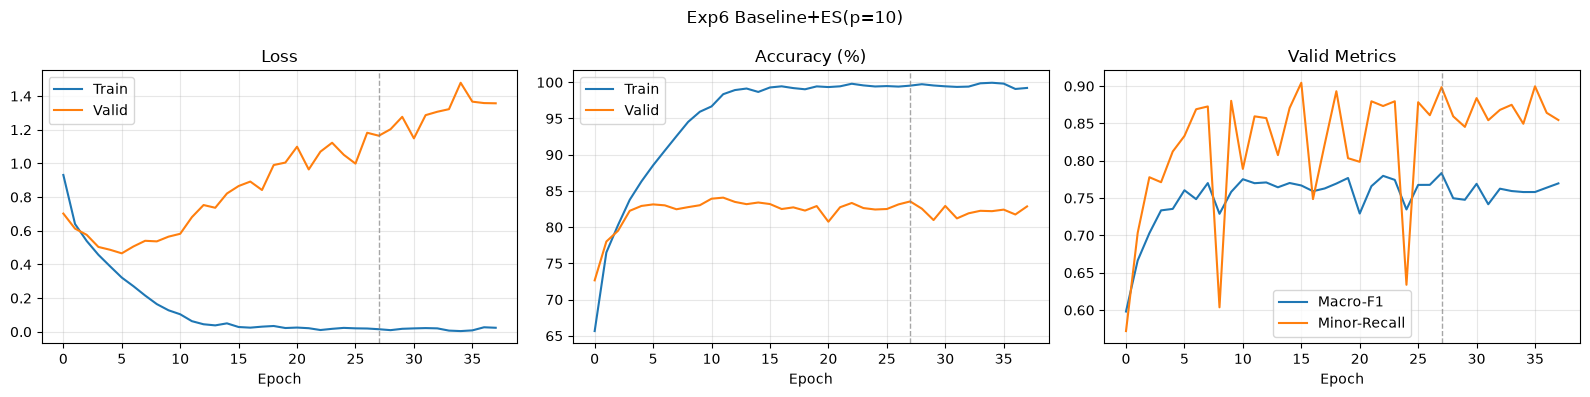

              precision    recall  f1-score   support

      Center     0.9049    0.9523    0.9280       859
       Donut     0.8000    0.9009    0.8475       111
    Edge-Loc     0.8045    0.7611    0.7822      1038
   Edge-Ring     0.9686    0.9716    0.9701      1936
         Loc     0.6736    0.7214    0.6967       718
   Near-full     1.0000    0.9333    0.9655        30
      Random     0.8613    0.8613    0.8613       173
     Scratch     0.3241    0.1967    0.2448       239
        none     0.7423    0.7690    0.7554      1000

    accuracy                         0.8355      6104
   macro avg     0.7866    0.7853    0.7835      6104
weighted avg     0.8288    0.8355    0.8311      6104

logged: exp6


In [9]:
# 실험 #6 브릿지 (Baseline + ES p=10)
set_seed(SEED)
model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

hist = train_model(model, train_loader, valid_loader, criterion, optimizer, device,
                   epochs=80, patience=10, ckpt_path='../ckpt/exp6_best.pt')
plot_curves(hist, 'Exp6 Baseline+ES(p=10)', '../results/figures/exp6_curves.png')
_, _, yt, yp = evaluate(model, valid_loader, criterion, device)
full_report(yt, yp)
log_result(RESULTS, 6, 'Baseline + ES (트랙B 기준점)', 'patience=10', hist, yt, yp)

layer                         params    share
---------------------------------------------
features.0.0                     320     0.1%
features.0.1                      64     0.0%
features.1.0                  18,496     7.6%
features.1.1                     128     0.1%
features.2.0                  73,856    30.5%
features.2.1                     256     0.1%
features.3.0                 147,584    61.0%
features.3.1                     256     0.1%
head.1                         1,161     0.5%
---------------------------------------------
TOTAL                        242,121
Ep  1  tr_loss 0.8260 tr_acc  71.98 | va_loss 0.8159 va_acc  69.90 va_F1 0.5969 va_minor 0.7947 *
Ep  2  tr_loss 0.5604 tr_acc  81.20 | va_loss 0.6735 va_acc  74.92 va_F1 0.6085 va_minor 0.4281 *
Ep  3  tr_loss 0.4732 tr_acc  84.05 | va_loss 0.5178 va_acc  80.70 va_F1 0.7115 va_minor 0.7389 *
Ep  4  tr_loss 0.4119 tr_acc  86.33 | va_loss 0.8264 va_acc  73.31 va_F1 0.5910 va_minor 0.4445
Ep  5  tr_loss 0.3574

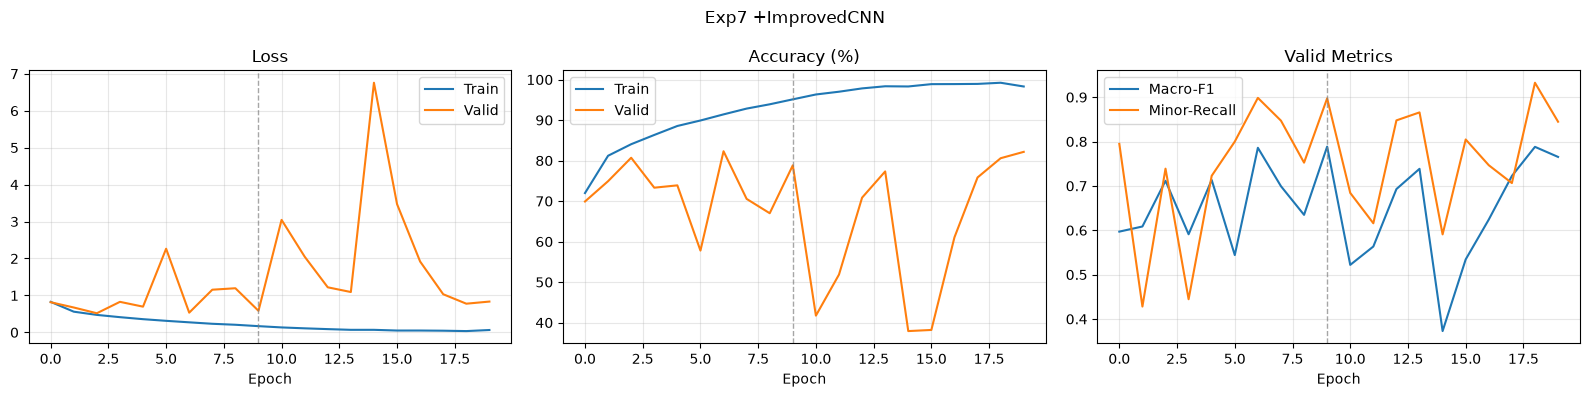

              precision    recall  f1-score   support

      Center     0.9130    0.9534    0.9328       859
       Donut     0.8990    0.8018    0.8476       111
    Edge-Loc     0.9128    0.5443    0.6820      1038
   Edge-Ring     0.9873    0.8027    0.8855      1936
         Loc     0.7914    0.7396    0.7646       718
   Near-full     0.6818    1.0000    0.8108        30
      Random     0.8324    0.8902    0.8603       173
     Scratch     0.7727    0.5690    0.6554       239
        none     0.5079    0.9340    0.6580      1000

    accuracy                         0.7883      6104
   macro avg     0.8109    0.8039    0.7886      6104
weighted avg     0.8467    0.7883    0.7953      6104

logged: exp7


In [10]:
# 실험 #7 +ImprovedCNN (Layer)
set_seed(SEED)
model = ImprovedCNN(dropout=0.0, use_bn=True).to(device)
count_params(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

hist = train_model(model, train_loader, valid_loader, criterion, optimizer, device,
                   epochs=80, patience=10, ckpt_path='../ckpt/exp7_best.pt')
plot_curves(hist, 'Exp7 +ImprovedCNN', '../results/figures/exp7_curves.png')
_, _, yt, yp = evaluate(model, valid_loader, criterion, device)
full_report(yt, yp)
log_result(RESULTS, 7, '+ImprovedCNN(GAP+BN)', 'ch=32/64/128/128, RF=46px', hist, yt, yp)

Ep  1  tr_loss 0.8360 tr_acc  71.27 | va_loss 0.8444 va_acc  68.51 va_F1 0.5481 va_minor 0.5278 *
Ep  2  tr_loss 0.5559 tr_acc  81.57 | va_loss 0.7246 va_acc  76.61 va_F1 0.6000 va_minor 0.6785 *
Ep  3  tr_loss 0.4727 tr_acc  84.17 | va_loss 0.7154 va_acc  72.79 va_F1 0.6938 va_minor 0.7728 *
Ep  4  tr_loss 0.4019 tr_acc  86.89 | va_loss 0.5794 va_acc  78.82 va_F1 0.7262 va_minor 0.6677 *
Ep  5  tr_loss 0.3657 tr_acc  88.12 | va_loss 0.8818 va_acc  73.46 va_F1 0.7219 va_minor 0.9173
Ep  6  tr_loss 0.3260 tr_acc  89.61 | va_loss 1.1632 va_acc  64.66 va_F1 0.6250 va_minor 0.8333
Ep  7  tr_loss 0.2877 tr_acc  90.96 | va_loss 0.5327 va_acc  83.93 va_F1 0.8013 va_minor 0.8875 *
Ep  8  tr_loss 0.2427 tr_acc  92.38 | va_loss 1.0741 va_acc  67.09 va_F1 0.6473 va_minor 0.6719
Ep  9  tr_loss 0.2062 tr_acc  93.89 | va_loss 0.6378 va_acc  80.18 va_F1 0.7604 va_minor 0.9165
Ep 10  tr_loss 0.1797 tr_acc  94.71 | va_loss 0.9430 va_acc  76.15 va_F1 0.6378 va_minor 0.4953
Ep 11  tr_loss 0.1472 tr_acc  

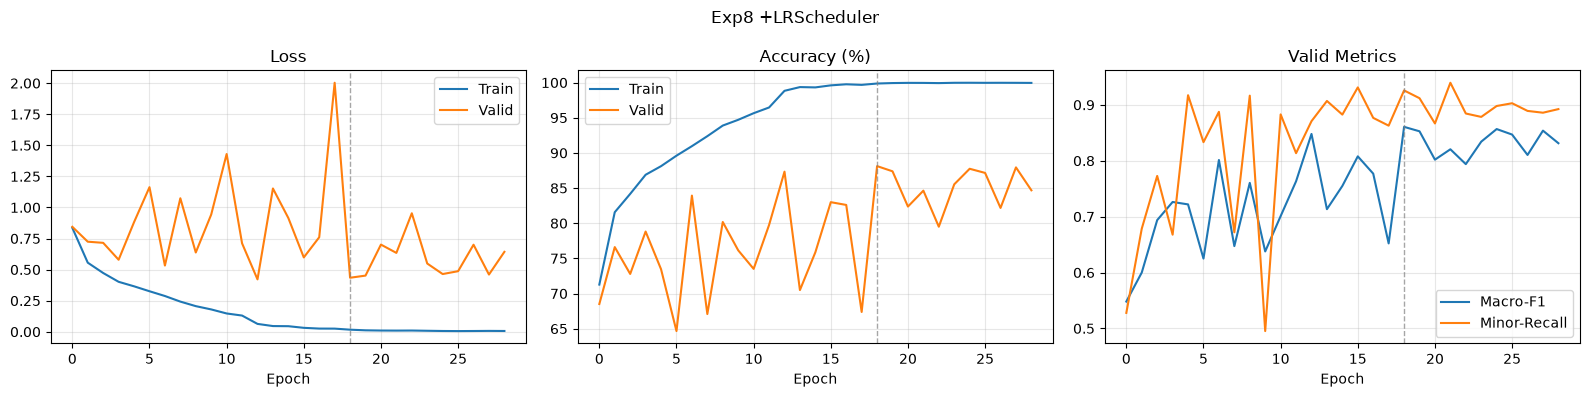

              precision    recall  f1-score   support

      Center     0.8942    0.9639    0.9277       859
       Donut     0.8034    0.8468    0.8246       111
    Edge-Loc     0.7949    0.8776    0.8342      1038
   Edge-Ring     0.9767    0.9757    0.9762      1936
         Loc     0.8372    0.6518    0.7330       718
   Near-full     0.9677    1.0000    0.9836        30
      Random     0.8750    0.9306    0.9020       173
     Scratch     0.8144    0.6611    0.7298       239
        none     0.8292    0.8400    0.8346      1000

    accuracy                         0.8812      6104
   macro avg     0.8659    0.8609    0.8606      6104
weighted avg     0.8812    0.8812    0.8790      6104

logged: exp8


In [11]:
# 실험 #8 +LR Scheduler(Optimizer)
set_seed(SEED)
model = ImprovedCNN(dropout=0.0, use_bn=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)

hist = train_model(model, train_loader, valid_loader, criterion, optimizer, device,
                   epochs=80, patience=10, ckpt_path='../ckpt/exp8_best.pt',
                   scheduler=scheduler)
plot_curves(hist, 'Exp8 +LRScheduler', '../results/figures/exp8_curves.png')
_, _, yt, yp = evaluate(model, valid_loader, criterion, device)
full_report(yt, yp)
log_result(RESULTS, 8, '+LR Scheduler', 'ReduceLROnPlateau(max,0.5,p=4)', hist, yt, yp)

Ep  1  tr_loss 0.8931 tr_acc  68.39 | va_loss 0.6935 va_acc  73.56 va_F1 0.6302 va_minor 0.7511 *
Ep  2  tr_loss 0.6238 tr_acc  78.82 | va_loss 1.2612 va_acc  52.72 va_F1 0.5198 va_minor 0.6244
Ep  3  tr_loss 0.5427 tr_acc  81.38 | va_loss 1.0577 va_acc  63.84 va_F1 0.5345 va_minor 0.7081
Ep  4  tr_loss 0.4928 tr_acc  83.44 | va_loss 0.8701 va_acc  70.35 va_F1 0.5704 va_minor 0.4394
Ep  5  tr_loss 0.4366 tr_acc  85.58 | va_loss 0.5066 va_acc  82.00 va_F1 0.7529 va_minor 0.8387 *
Ep  6  tr_loss 0.4013 tr_acc  86.96 | va_loss 0.5142 va_acc  83.31 va_F1 0.7865 va_minor 0.8806 *
Ep  7  tr_loss 0.3553 tr_acc  88.32 | va_loss 0.5760 va_acc  78.92 va_F1 0.7313 va_minor 0.6046
Ep  8  tr_loss 0.3379 tr_acc  89.04 | va_loss 0.6951 va_acc  75.72 va_F1 0.7548 va_minor 0.8654
Ep  9  tr_loss 0.3150 tr_acc  89.81 | va_loss 0.5588 va_acc  81.26 va_F1 0.8006 va_minor 0.8980 *
Ep 10  tr_loss 0.2833 tr_acc  90.90 | va_loss 0.7459 va_acc  77.10 va_F1 0.6818 va_minor 0.6766
Ep 11  tr_loss 0.2575 tr_acc  91

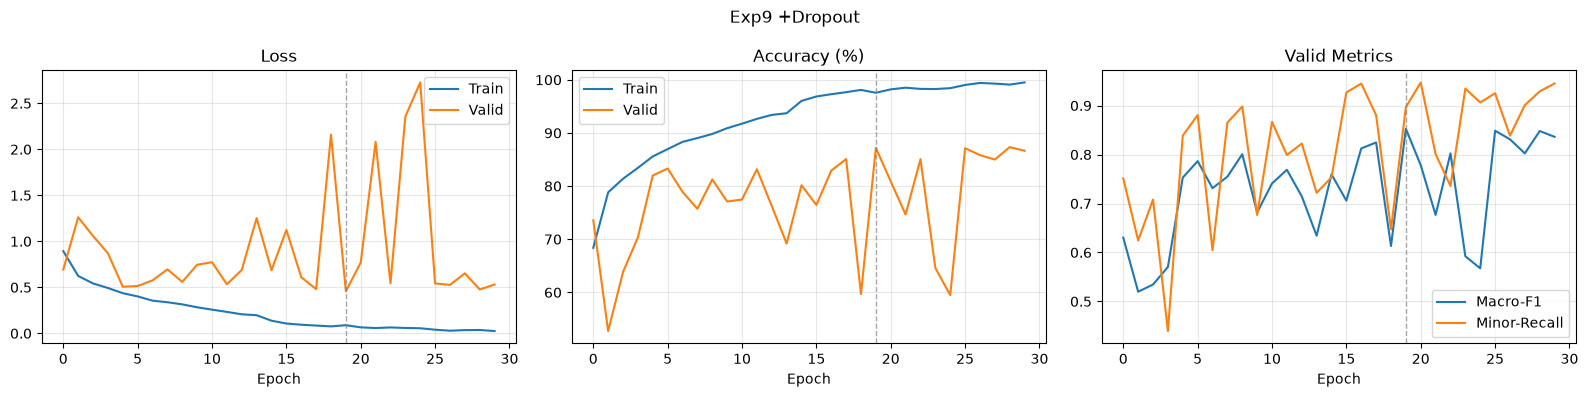

              precision    recall  f1-score   support

      Center     0.9406    0.9220    0.9312       859
       Donut     0.8679    0.8288    0.8479       111
    Edge-Loc     0.7371    0.8834    0.8037      1038
   Edge-Ring     0.9511    0.9948    0.9725      1936
         Loc     0.8230    0.6866    0.7487       718
   Near-full     0.9091    1.0000    0.9524        30
      Random     0.8922    0.8613    0.8765       173
     Scratch     0.6714    0.7950    0.7280       239
        none     0.9106    0.7330    0.8122      1000

    accuracy                         0.8719      6104
   macro avg     0.8559    0.8561    0.8526      6104
weighted avg     0.8772    0.8719    0.8707      6104

logged: exp9


In [12]:
# 실험 #9 +Dropout(규제)
set_seed(SEED)
model = ImprovedCNN(dropout=0.3, use_bn=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)

hist = train_model(model, train_loader, valid_loader, criterion, optimizer, device,
                   epochs=80, patience=10, ckpt_path='../ckpt/exp9_best.pt',
                   scheduler=scheduler)
plot_curves(hist, 'Exp9 +Dropout', '../results/figures/exp9_curves.png')
_, _, yt, yp = evaluate(model, valid_loader, criterion, device)
full_report(yt, yp)
log_result(RESULTS, 9, '+Dropout', 'p=0.3', hist, yt, yp)

Ep  1  tr_loss 0.8834 tr_acc  69.29 | va_loss 1.5870 va_acc  54.21 va_F1 0.4027 va_minor 0.5555 *
Ep  2  tr_loss 0.6261 tr_acc  78.84 | va_loss 0.9513 va_acc  70.58 va_F1 0.6057 va_minor 0.7286 *
Ep  3  tr_loss 0.5472 tr_acc  81.51 | va_loss 0.5655 va_acc  80.90 va_F1 0.7076 va_minor 0.7849 *
Ep  4  tr_loss 0.4854 tr_acc  83.69 | va_loss 0.6315 va_acc  76.05 va_F1 0.6749 va_minor 0.7318
Ep  5  tr_loss 0.4507 tr_acc  84.85 | va_loss 0.9718 va_acc  68.22 va_F1 0.6128 va_minor 0.7253
Ep  6  tr_loss 0.4069 tr_acc  86.68 | va_loss 0.8108 va_acc  69.48 va_F1 0.6817 va_minor 0.6823
Ep  7  tr_loss 0.3653 tr_acc  88.03 | va_loss 0.6227 va_acc  78.23 va_F1 0.7506 va_minor 0.9025 *
Ep  8  tr_loss 0.3342 tr_acc  89.35 | va_loss 0.4794 va_acc  83.24 va_F1 0.7993 va_minor 0.8221 *
Ep  9  tr_loss 0.3097 tr_acc  89.80 | va_loss 0.4734 va_acc  82.80 va_F1 0.7846 va_minor 0.7437
Ep 10  tr_loss 0.2847 tr_acc  90.61 | va_loss 0.7986 va_acc  74.10 va_F1 0.7238 va_minor 0.8539
Ep 11  tr_loss 0.2654 tr_acc  

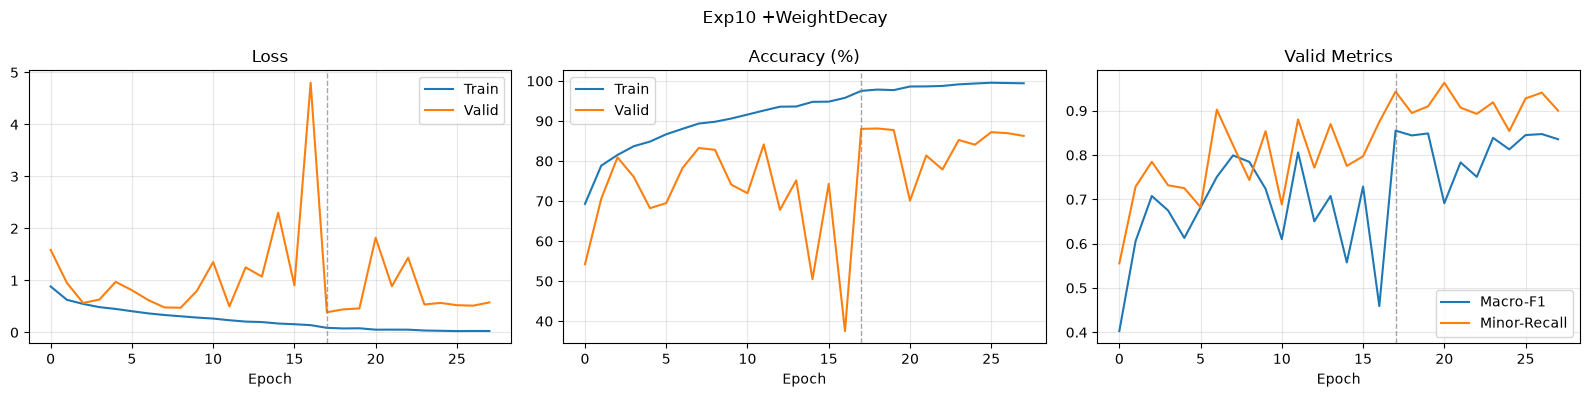

              precision    recall  f1-score   support

      Center     0.8914    0.9651    0.9268       859
       Donut     0.7829    0.9099    0.8417       111
    Edge-Loc     0.8945    0.7514    0.8168      1038
   Edge-Ring     0.9626    0.9830    0.9727      1936
         Loc     0.7589    0.7758    0.7672       718
   Near-full     0.8824    1.0000    0.9375        30
      Random     0.8238    0.9191    0.8689       173
     Scratch     0.7511    0.6946    0.7217       239
        none     0.8363    0.8480    0.8421      1000

    accuracy                         0.8802      6104
   macro avg     0.8427    0.8719    0.8550      6104
weighted avg     0.8805    0.8802    0.8788      6104

logged: exp10


In [13]:
# 실험 #10 +Weight Decay(규제)
set_seed(SEED)
model = ImprovedCNN(dropout=0.3, use_bn=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)

hist = train_model(model, train_loader, valid_loader, criterion, optimizer, device,
                   epochs=80, patience=10, ckpt_path='../ckpt/exp10_best.pt',
                   scheduler=scheduler)
plot_curves(hist, 'Exp10 +WeightDecay', '../results/figures/exp10_curves.png')
_, _, yt, yp = evaluate(model, valid_loader, criterion, device)
full_report(yt, yp)
log_result(RESULTS, 10, '+Weight Decay', 'wd=1e-5', hist, yt, yp)

Ep  1  tr_loss 0.9043 tr_acc  68.30 | va_loss 0.8293 va_acc  70.53 va_F1 0.4989 va_minor 0.4458 *
Ep  2  tr_loss 0.6393 tr_acc  78.40 | va_loss 0.6067 va_acc  80.90 va_F1 0.6914 va_minor 0.8261 *
Ep  3  tr_loss 0.5394 tr_acc  81.73 | va_loss 0.6519 va_acc  75.61 va_F1 0.6558 va_minor 0.6618
Ep  4  tr_loss 0.4836 tr_acc  83.57 | va_loss 0.5118 va_acc  82.50 va_F1 0.7880 va_minor 0.8192 *
Ep  5  tr_loss 0.4315 tr_acc  85.63 | va_loss 0.5769 va_acc  78.49 va_F1 0.7211 va_minor 0.6878
Ep  6  tr_loss 0.3968 tr_acc  86.90 | va_loss 0.6056 va_acc  81.42 va_F1 0.7775 va_minor 0.9529
Ep  7  tr_loss 0.3657 tr_acc  88.38 | va_loss 0.6631 va_acc  80.41 va_F1 0.6635 va_minor 0.5329
Ep  8  tr_loss 0.3312 tr_acc  88.98 | va_loss 0.6302 va_acc  77.72 va_F1 0.6917 va_minor 0.6889
Ep  9  tr_loss 0.3050 tr_acc  90.10 | va_loss 0.6494 va_acc  77.05 va_F1 0.7517 va_minor 0.7681
Ep 10  tr_loss 0.2392 tr_acc  92.50 | va_loss 0.4341 va_acc  84.49 va_F1 0.7945 va_minor 0.8004 *
Ep 11  tr_loss 0.2122 tr_acc  93

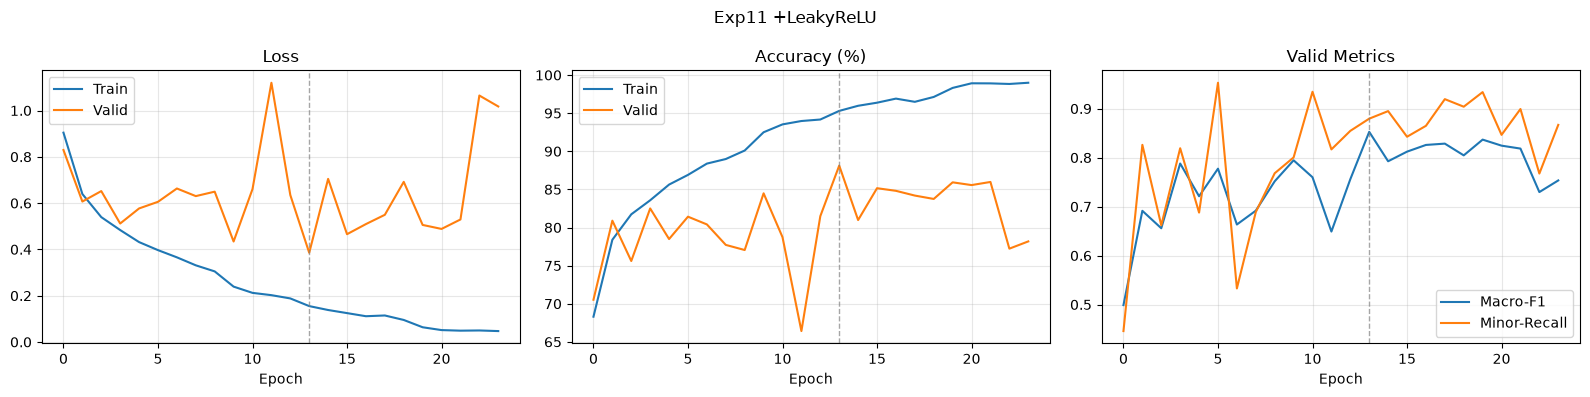

              precision    recall  f1-score   support

      Center     0.8548    0.9732    0.9102       859
       Donut     0.8866    0.7748    0.8269       111
    Edge-Loc     0.8513    0.8218    0.8363      1038
   Edge-Ring     0.9796    0.9659    0.9727      1936
         Loc     0.7513    0.7869    0.7687       718
   Near-full     0.9655    0.9333    0.9492        30
      Random     0.8256    0.9306    0.8750       173
     Scratch     0.9286    0.5439    0.6860       239
        none     0.8483    0.8500    0.8492      1000

    accuracy                         0.8812      6104
   macro avg     0.8768    0.8423    0.8527      6104
weighted avg     0.8837    0.8812    0.8797      6104

logged: exp11


In [14]:
# 실험 #11 — +LeakyReLU (Activation)

set_seed(SEED)
model = ImprovedCNN(dropout=0.3, use_bn=True, activation='leakyrelu').to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)

hist = train_model(model, train_loader, valid_loader, criterion, optimizer, device,
                   epochs=80, patience=10, ckpt_path='../ckpt/exp11_best.pt',
                   scheduler=scheduler)
plot_curves(hist, 'Exp11 +LeakyReLU', '../results/figures/exp11_curves.png')
_, _, yt, yp = evaluate(model, valid_loader, criterion, device)
full_report(yt, yp)
log_result(RESULTS, 11, '+LeakyReLU', 'negative_slope=0.01', hist, yt, yp)

Ep  1  tr_loss 0.9413 tr_acc  66.76 | va_loss 0.8320 va_acc  66.87 va_F1 0.5708 va_minor 0.6004 *
Ep  2  tr_loss 0.6750 tr_acc  76.90 | va_loss 0.6289 va_acc  77.41 va_F1 0.6318 va_minor 0.5465 *
Ep  3  tr_loss 0.5927 tr_acc  79.64 | va_loss 0.6009 va_acc  80.70 va_F1 0.7219 va_minor 0.9283 *
Ep  4  tr_loss 0.5422 tr_acc  82.13 | va_loss 0.5089 va_acc  82.96 va_F1 0.6947 va_minor 0.6004
Ep  5  tr_loss 0.5101 tr_acc  82.58 | va_loss 0.6406 va_acc  77.26 va_F1 0.6921 va_minor 0.7618
Ep  6  tr_loss 0.4784 tr_acc  83.81 | va_loss 0.6721 va_acc  76.67 va_F1 0.7380 va_minor 0.8736 *
Ep  7  tr_loss 0.4596 tr_acc  84.67 | va_loss 0.4968 va_acc  84.09 va_F1 0.7851 va_minor 0.8370 *
Ep  8  tr_loss 0.4496 tr_acc  85.17 | va_loss 0.5551 va_acc  82.29 va_F1 0.7756 va_minor 0.9016
Ep  9  tr_loss 0.4278 tr_acc  86.06 | va_loss 0.3794 va_acc  88.25 va_F1 0.8594 va_minor 0.8631 *
Ep 10  tr_loss 0.4104 tr_acc  86.41 | va_loss 0.6025 va_acc  80.73 va_F1 0.7653 va_minor 0.7592
Ep 11  tr_loss 0.3912 tr_acc

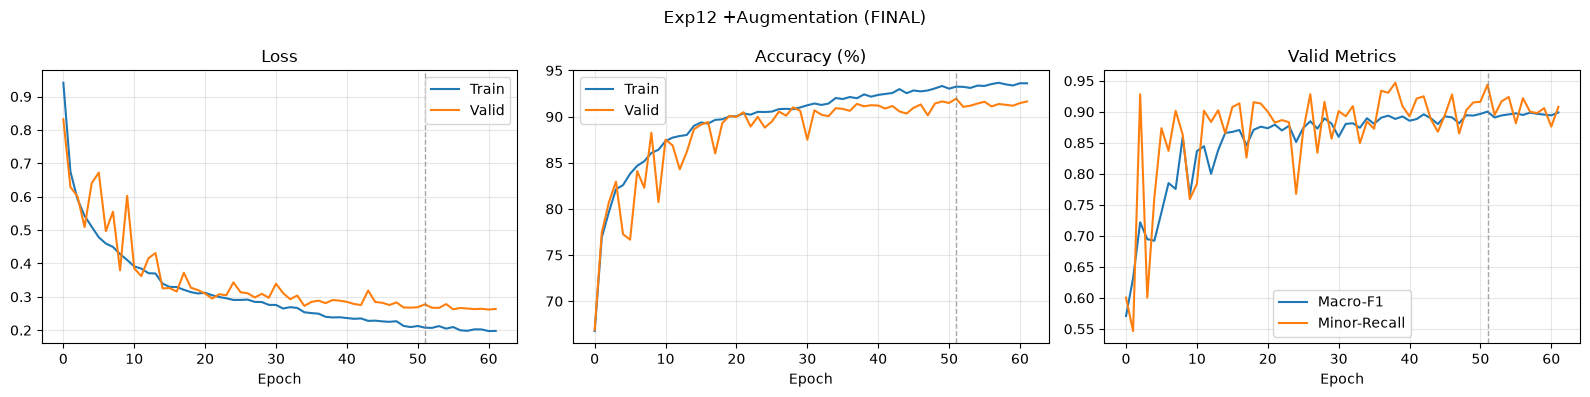

              precision    recall  f1-score   support

      Center     0.9473    0.9627    0.9550       859
       Donut     0.8547    0.9009    0.8772       111
    Edge-Loc     0.8890    0.8719    0.8804      1038
   Edge-Ring     0.9755    0.9892    0.9823      1936
         Loc     0.8090    0.8733    0.8399       718
   Near-full     0.8571    1.0000    0.9231        30
      Random     0.8798    0.9306    0.9045       173
     Scratch     0.8834    0.8243    0.8528       239
        none     0.9280    0.8510    0.8878      1000

    accuracy                         0.9196      6104
   macro avg     0.8915    0.9115    0.9003      6104
weighted avg     0.9204    0.9196    0.9194      6104

logged: exp12


In [15]:
# 실험 #12 +Augmentation (최종)
set_seed(SEED)
train_loader_aug, _, _ = make_loaders(data, batch_size=64, seed=SEED, augment=True)

BEST_ACT = 'leakyrelu'      # ← #11 결과 보고 'relu'/'leakyrelu' 중 선택

model = ImprovedCNN(dropout=0.3, use_bn=True, activation=BEST_ACT).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)

hist = train_model(model, train_loader_aug, valid_loader, criterion, optimizer, device,
                   epochs=80, patience=10, ckpt_path='../ckpt/exp12_best.pt',
                   scheduler=scheduler)
plot_curves(hist, 'Exp12 +Augmentation (FINAL)', '../results/figures/exp12_curves.png')
_, _, yt, yp = evaluate(model, valid_loader, criterion, device)
full_report(yt, yp)
log_result(RESULTS, 12, '+Augmentation', f'rot90/flip, act={BEST_ACT}', hist, yt, yp)

## 최종 Test 평가 (1회)
Valid-Macro-F1 기준으로 최적 조합 확정 후 Test 1회 평가.

In [16]:
# 결과 요약
import pandas as pd
df = pd.read_csv(RESULTS)
cols = ['exp','desc','best_epoch','train_acc','valid_acc','gap',
        'valid_macro_f1','valid_minor_recall']
print(df[cols].to_string(index=False))
print("\nBest by Valid-Macro-F1: exp", df.loc[df['valid_macro_f1'].idxmax(), 'exp'])

 exp                    desc  best_epoch  train_acc  valid_acc   gap  valid_macro_f1  valid_minor_recall
   1                Baseline          28     0.9901     0.8406 14.95          0.7851              0.8783
   2         +Early Stopping           7     0.9149     0.8398  7.51          0.7914              0.9340
   3           +Class Weight           9     0.9033     0.8137  8.96          0.7639              0.8686
   4                +Dropout          21     0.8689     0.8182  5.08          0.7623              0.8898
   5           +Weight Decay          17     0.7654     0.7987 -3.33          0.7529              0.9359
   6 Baseline + ES (트랙B 기준점)          28     0.9954     0.8355 15.98          0.7835              0.8985
   7    +ImprovedCNN(GAP+BN)          10     0.9512     0.7883 16.29          0.7886              0.8973
   8           +LR Scheduler          19     0.9987     0.8812 11.75          0.8606              0.9258
   9                +Dropout          20     0.9756    

In [17]:
# Test 평가
BEST_EXP = 12                # ← 위 출력 확인 후 확정
BEST_ACT = 'leakyrelu'       # ← 해당 실험의 activation

model = ImprovedCNN(dropout=0.3, use_bn=True, activation=BEST_ACT).to(device)
model.load_state_dict(torch.load(f'../ckpt/exp{BEST_EXP}_best.pt', map_location=device))

_, test_acc, yt, yp = evaluate(model, test_loader, nn.CrossEntropyLoss(), device)
mn, r = minor_recall(yt, yp)

print(f"Test-Accuracy    : {test_acc/100:.4f}")
print(f"Test-Macro-F1    : {f1_score(yt, yp, average='macro', zero_division=0):.4f}")
print(f"Test-Recall(mean): {r.mean():.4f}")
print(f"Test-Recall(소수): {mn:.4f}\n")
full_report(yt, yp)

Test-Accuracy    : 0.9140
Test-Macro-F1    : 0.8805
Test-Recall(mean): 0.8890
Test-Recall(소수): 0.8765

              precision    recall  f1-score   support

      Center     0.9387    0.9627    0.9506       859
       Donut     0.8017    0.8378    0.8194       111
    Edge-Loc     0.8701    0.8844    0.8772      1038
   Edge-Ring     0.9819    0.9819    0.9819      1936
         Loc     0.8147    0.8498    0.8319       719
   Near-full     0.8667    0.8667    0.8667        30
      Random     0.8163    0.9249    0.8672       173
     Scratch     0.8354    0.8529    0.8441       238
        none     0.9365    0.8400    0.8856      1000

    accuracy                         0.9140      6104
   macro avg     0.8736    0.8890    0.8805      6104
weighted avg     0.9154    0.9140    0.9141      6104



In [18]:
# Baseline Test 평가 (비교 기준 확보용, 최종 조합 확정 후 수행)
model_bl = BaselineCNN().to(device)
model_bl.load_state_dict(torch.load('../ckpt/exp1_best.pt', map_location=device))

_, bl_acc, yt_bl, yp_bl = evaluate(model_bl, test_loader, nn.CrossEntropyLoss(), device)
mn_bl, r_bl = minor_recall(yt_bl, yp_bl)

print(f"[Baseline Test] Accuracy    : {bl_acc/100:.4f}")
print(f"[Baseline Test] Macro-F1    : {f1_score(yt_bl, yp_bl, average='macro', zero_division=0):.4f}")
print(f"[Baseline Test] Recall(mean): {r_bl.mean():.4f}")
print(f"[Baseline Test] Recall(소수): {mn_bl:.4f}\n")
full_report(yt_bl, yp_bl)

[Baseline Test] Accuracy    : 0.8270
[Baseline Test] Macro-F1    : 0.7552
[Baseline Test] Recall(mean): 0.7461
[Baseline Test] Recall(소수): 0.8010

              precision    recall  f1-score   support

      Center     0.9018    0.9406    0.9208       859
       Donut     0.7909    0.7838    0.7873       111
    Edge-Loc     0.7625    0.7669    0.7646      1038
   Edge-Ring     0.9632    0.9742    0.9687      1936
         Loc     0.7120    0.6259    0.6662       719
   Near-full     0.9545    0.7000    0.8077        30
      Random     0.8238    0.9191    0.8689       173
     Scratch     0.3187    0.2143    0.2563       238
        none     0.7254    0.7900    0.7563      1000

    accuracy                         0.8270      6104
   macro avg     0.7726    0.7461    0.7552      6104
weighted avg     0.8196    0.8270    0.8221      6104



In [19]:
# Baseline Test 평가 (비교 기준 확보용, 최종 조합 확정 후 수행)
model_bl = BaselineCNN().to(device)
model_bl.load_state_dict(torch.load('../ckpt/exp1_best.pt', map_location=device))

_, bl_acc, yt_bl, yp_bl = evaluate(model_bl, test_loader, nn.CrossEntropyLoss(), device)
mn_bl, r_bl = minor_recall(yt_bl, yp_bl)

print(f"[Baseline Test] Accuracy    : {bl_acc/100:.4f}")
print(f"[Baseline Test] Macro-F1    : {f1_score(yt_bl, yp_bl, average='macro', zero_division=0):.4f}")
print(f"[Baseline Test] Recall(mean): {r_bl.mean():.4f}")
print(f"[Baseline Test] Recall(소수): {mn_bl:.4f}\n")
full_report(yt_bl, yp_bl)

[Baseline Test] Accuracy    : 0.8270
[Baseline Test] Macro-F1    : 0.7552
[Baseline Test] Recall(mean): 0.7461
[Baseline Test] Recall(소수): 0.8010

              precision    recall  f1-score   support

      Center     0.9018    0.9406    0.9208       859
       Donut     0.7909    0.7838    0.7873       111
    Edge-Loc     0.7625    0.7669    0.7646      1038
   Edge-Ring     0.9632    0.9742    0.9687      1936
         Loc     0.7120    0.6259    0.6662       719
   Near-full     0.9545    0.7000    0.8077        30
      Random     0.8238    0.9191    0.8689       173
     Scratch     0.3187    0.2143    0.2563       238
        none     0.7254    0.7900    0.7563      1000

    accuracy                         0.8270      6104
   macro avg     0.7726    0.7461    0.7552      6104
weighted avg     0.8196    0.8270    0.8221      6104

